#No 2

###A.EDA


In [1]:
#import library
import zipfile
import os
from glob import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import tensorflow as tf
import pandas as pd
import datetime
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.initializers import HeNormal, GlorotUniform



In [2]:
#Ekstrak file zip
zip_path = '/content/A_23-20250626T091625Z-1-001.zip'
extract_path = '/content/A_23_images'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

**MENENTUKAN JUMLAH DAN FORMAT FILE GAMBAR**

Tujuan: Untuk memastikan semua file valid dan tidak corrupt, serta tahu jumlah data.

In [3]:
#Load semua gambar dari folder hasil ekstrak
image_paths = glob(os.path.join(extract_path, '**/*.jpg'), recursive=True)  # jika di dalam subfolder
print(f"Jumlah gambar ditemukan: {len(image_paths)}")

Jumlah gambar ditemukan: 1074


In [4]:
print(image_paths[0])

/content/A_23_images/A_23/siirt 60.jpg


In [5]:
img = Image.open(image_paths[0])
img_arr = np.array(img)

print(f"Dimensi gambar: {img_arr.shape}")
print(f"Tipe data pixel: {img_arr.dtype}")

Dimensi gambar: (600, 600, 3)
Tipe data pixel: uint8


**CEK FORMAT DAN DIMENSI GAMBAR**

Tujuan: Memastikan semua gambar memiliki resolusi dan format channel yang konsisten.

In [6]:
dims = []
modes = []

for img_path in image_paths:
    with Image.open(img_path) as img:
        dims.append(img.size)
        modes.append(img.mode)

import pandas as pd
df = pd.DataFrame({'dimensi': dims, 'mode': modes})
print(df['dimensi'].value_counts())
print(df['mode'].value_counts())

dimensi
(600, 600)    1074
Name: count, dtype: int64
mode
RGB    1074
Name: count, dtype: int64


**VISUALISASI CONTOH GAMBAR**

Tujuan: Memahami konten visual: objek, noise alami, keragaman.

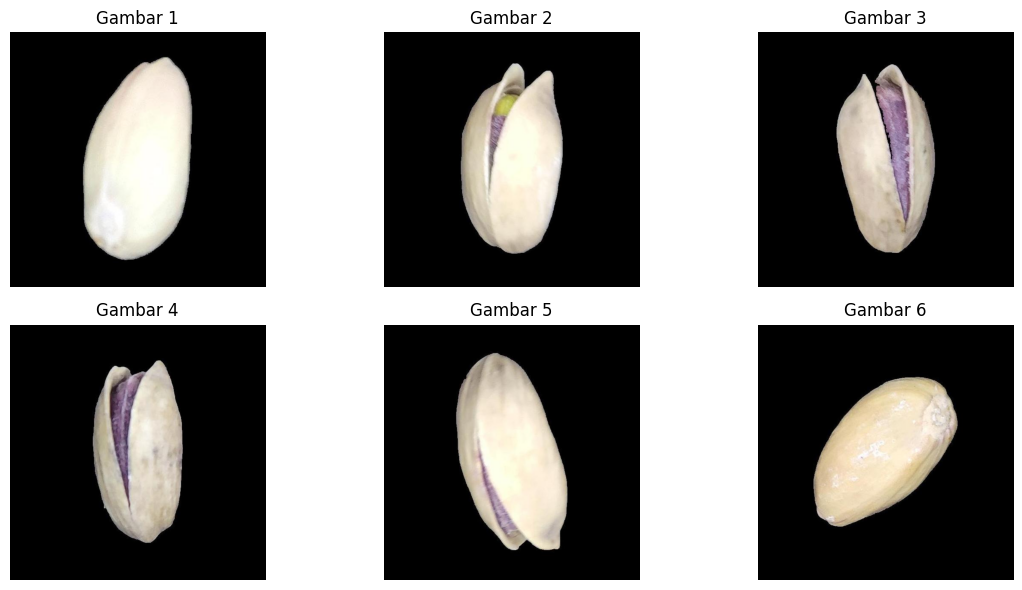

In [7]:
plt.figure(figsize=(12, 6))
for i in range(6):
    img = Image.open(image_paths[i])
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f'Gambar {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

**DISTRIBUSI NILAI PIXEL**

Tujuan: Mengetahui skala nilai pixel (0-255), dan sebarannya, penting untuk normalisasi.

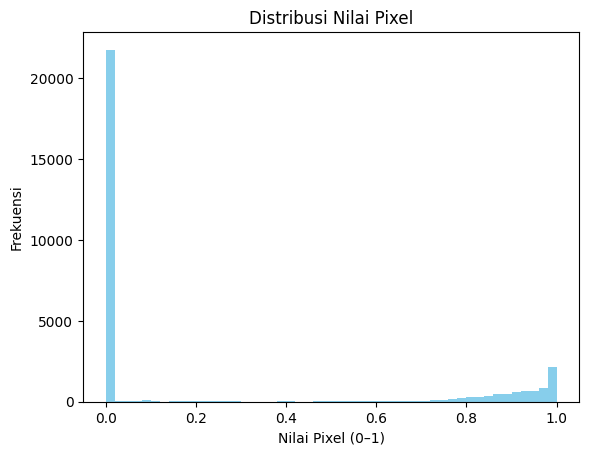

In [8]:
img = Image.open(image_paths[0]).resize((100, 100))
img_arr = np.array(img) / 255.0  # Normalisasi agar antara 0–1

plt.hist(img_arr.ravel(), bins=50, color='skyblue')
plt.title("Distribusi Nilai Pixel")
plt.xlabel("Nilai Pixel (0–1)")
plt.ylabel("Frekuensi")
plt.show()

Distribusi nilai piksel menunjukkan dominasi intensitas rendah (mendekati 0), mengindikasikan bahwa sebagian besar gambar dalam dataset memiliki latar atau area dominan gelap. Hal ini penting diketahui agar model dapat didesain untuk menangkap pola dari piksel dengan kontras rendah dan tidak overfitting pada area kosong. Selain itu, perlu pertimbangan khusus dalam preprocessing untuk memastikan bahwa informasi visual penting tetap bisa ditangkap oleh model.


**ANALISIS CHANNEL WARNA(RGB)**

Tujuan: Memeriksa sebaran per channel, apakah distribusinya seimbang.

- Mengetahui apakah gambar lebih dominan di salah satu channel warna.




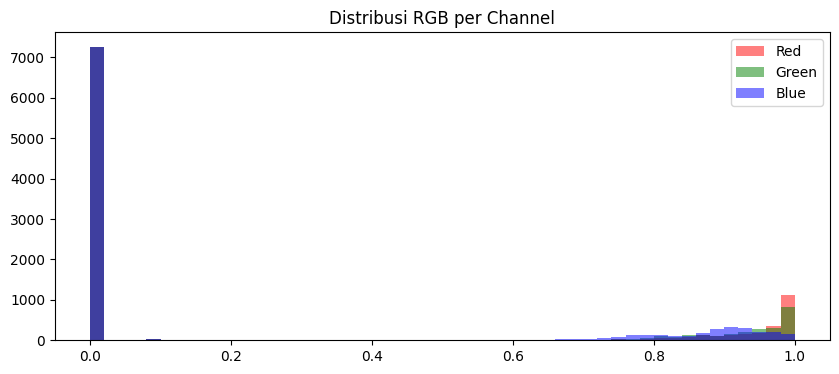

In [9]:
r, g, b = img_arr[:,:,0], img_arr[:,:,1], img_arr[:,:,2]
plt.figure(figsize=(10, 4))
plt.hist(r.ravel(), bins=50, color='red', alpha=0.5, label='Red')
plt.hist(g.ravel(), bins=50, color='green', alpha=0.5, label='Green')
plt.hist(b.ravel(), bins=50, color='blue', alpha=0.5, label='Blue')
plt.legend()
plt.title("Distribusi RGB per Channel")
plt.show()

- Sebagian besar piksel bernilai sangat rendah (mendekati 0) → ini terlihat dari spike besar di kiri grafik.

- Distribusi nilai tinggi (sekitar 1.0) cukup banyak untuk Red, Green, Blue — tetapi tidak merata.

- Blue channel tampaknya punya persebaran yang sedikit berbeda dibanding Red/Green → mungkin lebih dominan atau noise berbeda.

**ANALISI PERBEDAAN GAMBAR**

Tujuan: Menghitung standar deviasi antar gambar untuk memahami variasi konten.

- Area dengan variansi tinggi → objek berubah-ubah.

- Area dengan variansi rendah → background konstan.



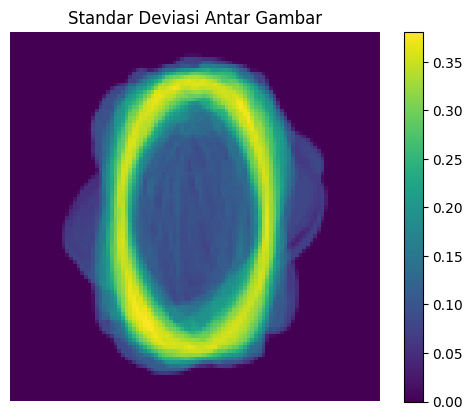

In [10]:
all_imgs = []
for path in image_paths[:100]:  # cukup subset
    img = Image.open(path).resize((100, 100))
    arr = np.array(img) / 255.0
    all_imgs.append(arr)

all_imgs = np.array(all_imgs)
std_dev = np.std(all_imgs, axis=0)

plt.imshow(np.mean(std_dev, axis=2), cmap='viridis')
plt.colorbar()
plt.title("Standar Deviasi Antar Gambar")
plt.axis('off')
plt.show()

Interpretasi Heatmap Standar Deviasi

Gambar ini menunjukkan seberapa besar variasi nilai piksel di setiap lokasi (x, y) di seluruh gambar pada dataset.

Warna kuning/terang menunjukkan area dengan variasi tinggi antar gambar, sedangkan ungu/gelap menunjukkan area yang relatif konstan.

**Berdasarkan gambar:**

- Terlihat ada pola oval di tengah yang punya standar deviasi tinggi → artinya objek utama dalam gambar berada di tengah, dan bentuk objek bisa bervariasi antar sampel.

- Area luar (background) cenderung tidak berubah → sesuai dengan ekspektasi untuk dataset terpusat.

**DETEKSI GAMBAR KSOSONG/TIDAK VALID**

Tujuan: Membersihkan data sebelum training.


In [11]:
corrupt = []
for path in image_paths:
    try:
        Image.open(path).verify()
    except:
        corrupt.append(path)

print(f"Jumlah gambar corrupt: {len(corrupt)}")

Jumlah gambar corrupt: 0


**IMAGE SHARPNESS CHECK**

Tujuan: Mengidentifikasi apakah gambar blur/tidak tajam (bisa jadi noise alami).

Metode: Variance of Laplacian, nilai kecil berarti gambar blur.

- Interpretasi: Jika banyak gambar memiliki nilai < 50 → banyak gambar blur, bisa mempengaruhi hasil denoising.



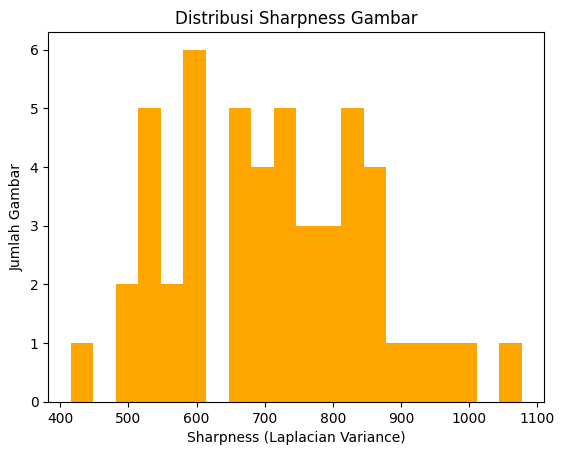

In [12]:
def calculate_sharpness(img_arr):
    gray = cv2.cvtColor((img_arr * 255).astype('uint8'), cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

sharpness_scores = []
for path in image_paths[:50]:
    img = Image.open(path).resize((100, 100))
    img_arr = np.array(img) / 255.0
    sharpness_scores.append(calculate_sharpness(img_arr))

plt.hist(sharpness_scores, bins=20, color='orange')
plt.title("Distribusi Sharpness Gambar")
plt.xlabel("Sharpness (Laplacian Variance)")
plt.ylabel("Jumlah Gambar")
plt.show()

**Puncak Distribusi**

- Histogram menunjukkan jumlah gambar terbanyak memiliki sharpness di kisaran 600-650, dengan 6 gambar.

- Ini adalah mode distribusi — mayoritas gambar berada pada level ketajaman sedang.

**Sebaran Umum**

- Distribusi terlihat relatif merata namun sedikit condong ke kiri (left-skewed).

- Ada gambar dengan sharpness rendah (sekitar 400) dan beberapa yang sangat tinggi (>1000), tetapi jumlahnya sedikit (outlier).

**Distribusi Gambar**

- Gambar dengan sharpness < 550: tergolong agak blur.

- Gambar dengan sharpness > 900: sangat tajam.

- Sebagian besar gambar berada dalam rentang 600-850, yang menunjukkan kualitas tajam yang stabil.


---

kesimpulan:

- Mayoritas gambar memiliki kualitas tajam yang cukup baik (sharpness menengah hingga tinggi).

- Terdapat beberapa gambar blur (low sharpness) yang mungkin perlu ditinjau atau ditingkatkan jika kualitas penting (misalnya dalam klasifikasi).

- Outlier di kedua sisi (sangat blur atau sangat tajam) patut dianalisis lebih lanjut — bisa jadi artefak kompresi, noise, atau gambar dengan edge ekstrem.


**IMAGE SIMILARITY CHECK(COSINE SIMILARITY VIA FLATTENED IMAGE)**

Tujuan: Mengetahui apakah banyak gambar terlalu mirip → overfitting risk.

- Image Similarity menggunakan Cosine Similarity antar gambar setelah flattening, untuk mengevaluasi keberagaman gambar.

- Interpretasi: Jika banyak nilai similarity > 0.9, maka dataset terlalu mirip, bisa jadi tantangan bagi autoencoder.


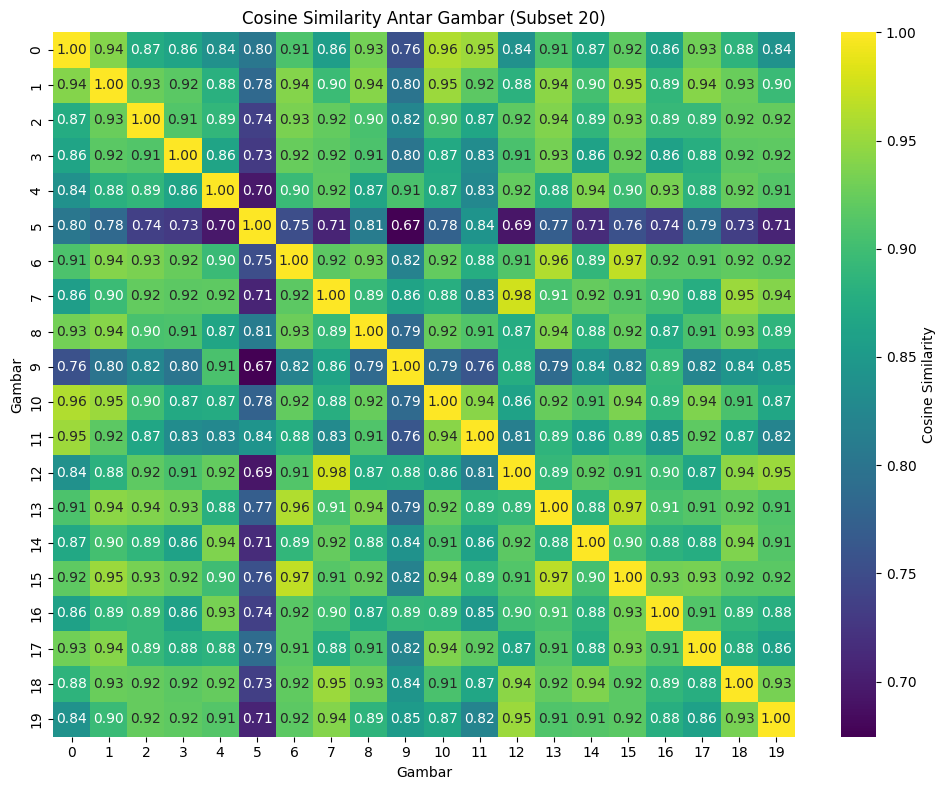

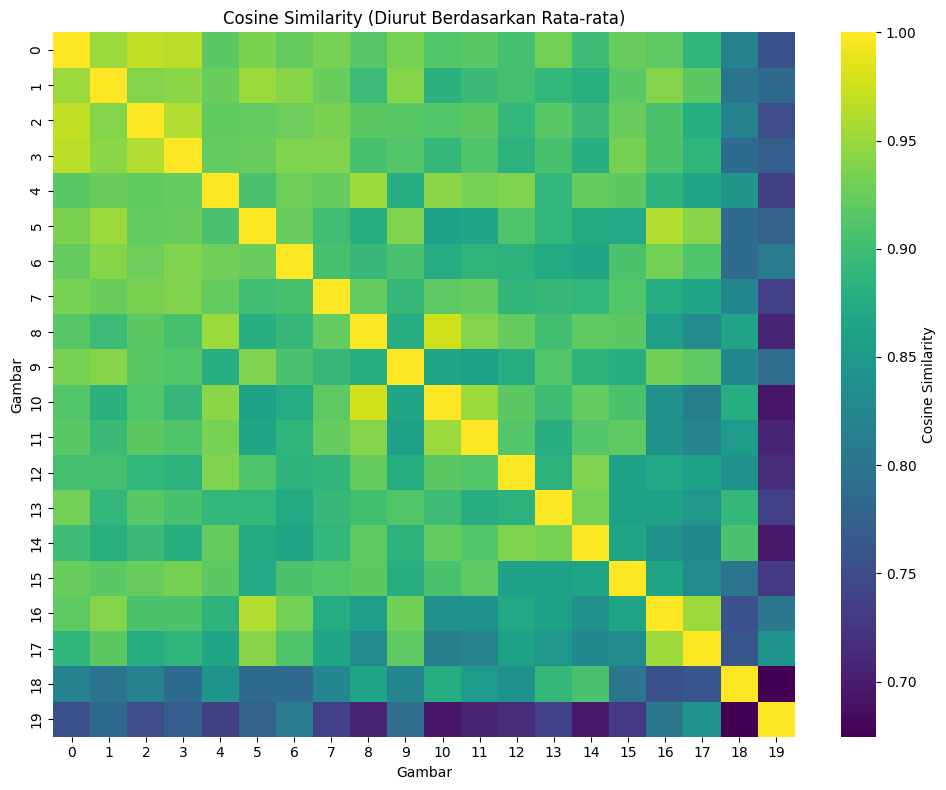

In [13]:
# Ambil subset 20 gambar dari image_paths (pastikan sudah terdefinisi)
subset_imgs = []
for path in image_paths[:20]:  # atau gunakan path dari datasetmu
    img = Image.open(path).resize((100, 100))
    img_arr = np.array(img) / 255.0
    subset_imgs.append(img_arr.flatten())

subset_imgs = np.array(subset_imgs)

# Hitung cosine similarity
sim_matrix = cosine_similarity(subset_imgs)


# Konversi ke DataFrame agar bisa pakai seaborn heatmap
df_sim = pd.DataFrame(sim_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(df_sim, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Cosine Similarity'})
plt.title("Cosine Similarity Antar Gambar (Subset 20)")
plt.xlabel("Gambar")
plt.ylabel("Gambar")
plt.tight_layout()
plt.show()

# Urutkan index berdasarkan rata-rata similarity
mean_sim = np.mean(sim_matrix, axis=1)
sorted_idx = np.argsort(-mean_sim)  # descending

sim_sorted = sim_matrix[sorted_idx][:, sorted_idx]
df_sim_sorted = pd.DataFrame(sim_sorted)

plt.figure(figsize=(10, 8))
sns.heatmap(df_sim_sorted, annot=False, cmap='viridis', cbar_kws={'label': 'Cosine Similarity'})
plt.title("Cosine Similarity (Diurut Berdasarkan Rata-rata)")
plt.xlabel("Gambar")
plt.ylabel("Gambar")
plt.tight_layout()
plt.show()

Hasil Analisis:

**Kemiripan Tinggi (>0.95)**

Banyak pasangan gambar yang memiliki nilai >0.95 — ini menunjukkan bahwa ada kemiripan visual atau fitur yang sangat tinggi antar gambar tertentu.

**Contoh pasangan dengan similarity tinggi:**

- Gambar 1 & 13: 0.95

- Gambar 6 & 15: 0.97

- Gambar 13 & 14: 0.97

**Kemiripan Rendah (<0.75)**

Beberapa gambar memiliki kemiripan rendah terhadap yang lain, contohnya:

- Gambar 5 dengan 6 (0.67)

- Gambar 4 dengan 12 (0.69)

Ini menunjukkan adanya outlier atau gambar dengan fitur unik.

**Distribusi Warna**

- Sebagian besar sel berwarna hijau terang (nilai 0.85-0.95), menunjukkan bahwa mayoritas gambar masih relatif mirip satu sama lain.

- Warna ungu tua pada beberapa titik menunjukkan kemiripan yang sangat rendah — ini penting untuk deteksi anomali atau klasifikasi.

**PCA CLUSTERING ANALYSIS**

Tujuan: Memahami apakah gambar memiliki pola klaster visual yang bisa dibedakan.

- PCA Clustering untuk memahami distribusi visual antar gambar dan kemungkinan keberadaan klaster

- Interpretasi: Jika titik menyebar → gambar cukup bervariasi. Jika menumpuk → data mirip atau repetitif.

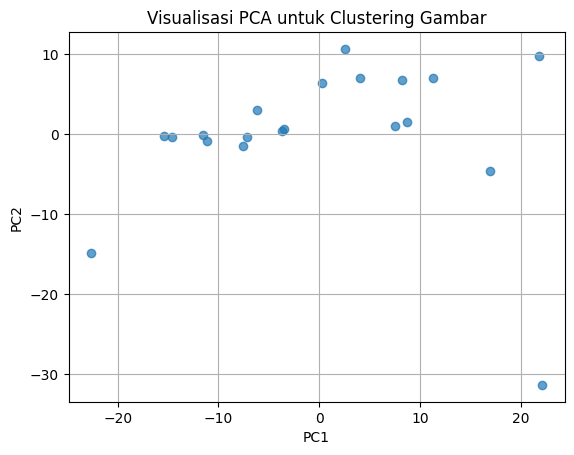

In [14]:
# PCA (bisa juga pakai t-SNE)
pca = PCA(n_components=2)
features = pca.fit_transform(subset_imgs)

plt.scatter(features[:, 0], features[:, 1], alpha=0.7)
plt.title("Visualisasi PCA untuk Clustering Gambar")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

**Distribusi Titik:**

Titik-titik tersebar dalam rentang yang luas di sepanjang sumbu PC1 dan PC2.

Ini menunjukkan bahwa data memiliki variasi yang signifikan yang berhasil ditangkap oleh dua komponen utama.

**Potensi Klaster:**

Terdapat beberapa kelompok titik yang terlihat lebih rapat satu sama lain, yang mengindikasikan potensi klaster alami.

Misalnya, ada kelompok di sekitar koordinat (0, 8), (-10, 0), dan (10, 0~8) yang mungkin menunjukkan kemiripan fitur visual antar gambar.

**Outlier:**

Beberapa titik berada jauh dari yang lain, misalnya di sekitar (-23, -15) dan (22, -31), yang bisa jadi merupakan outlier atau gambar dengan fitur sangat berbeda.

###B.REPROCESSING

**LOAD DAN RESIZE SEMUA GAMBAR**

- Semua gambar diresize menjadi ukuran 100x100 piksel dan dinormalisasi ke rentang [0, 1]. Ini diperlukan agar input memiliki dimensi konsisten untuk digunakan pada model convolutional


In [15]:
# Resize & normalisasi semua gambar
resized_images = []
for path in image_paths:
    img = Image.open(path).resize((100, 100))
    img_arr = np.array(img) / 255.0  # Normalisasi ke [0, 1]
    resized_images.append(img_arr)

resized_images = np.array(resized_images)
print(f"Shape data setelah resize: {resized_images.shape}")  # (n_samples, 100, 100, 3)

Shape data setelah resize: (1074, 100, 100, 3)


**SPLIT DATA 80%TRAIN, 10%VAL, 10%TEST**

- Dataset dibagi menjadi 80% data latih, 10% validasi, dan 10% pengujian untuk menjaga generalisasi model dan evaluasi yang adil



In [16]:
# Split menjadi 80-10-10
train_val, test = train_test_split(resized_images, test_size=0.1, random_state=42)
train, val = train_test_split(train_val, test_size=0.1111, random_state=42)  # 10% dari total

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

Train: (858, 100, 100, 3), Val: (108, 100, 100, 3), Test: (108, 100, 100, 3)


- Training Set: (858, 100, 100, 3) → 858 gambar

- Validation Set: (108, 100, 100, 3) → 108 gambar

- Test Set: (108, 100, 100, 3) → 108 gambar


---
Ini adalah pembagian standar dan seimbang, sangat ideal untuk pelatihan dan evaluasi model karena:

- Training cukup banyak untuk belajar pola

- Validation cukup untuk pemantauan selama training (misal, early stopping)

- Test cukup untuk evaluasi performa akhir secara adil


---


Alasan Dilakukan

- Memastikan tidak terjadi data leakage antar set

- Menjamin bahwa evaluasi model fair dan representatif

- Memastikan jumlah data cukup di setiap bagian agar model bisa belajar dengan baik tanpa overfitting atau underfitting




**TAMBAHKAN GAUSSIAN NOISE**

- Noise acak ditambahkan ke gambar berdasarkan distribusi normal dengan rata-rata 0.0 dan deviasi standar 0.1. Nilai kemudian diklip agar tetap dalam range [0, 1]. Tujuannya adalah melatih model autoencoder agar mampu membersihkan noise secara efisien


In [17]:
# Add Gaussian noise
def add_gaussian_noise(images, mean=0.0, std=0.1):
    noise = np.random.normal(loc=mean, scale=std, size=images.shape)
    noisy_images = images + noise
    return np.clip(noisy_images, 0., 1.)

In [18]:
# Tambahkan noise ke masing-masing set
x_train = train
x_val = val
x_test = test
x_train_noisy = add_gaussian_noise(x_train)
x_val_noisy = add_gaussian_noise(x_val)
x_test_noisy = add_gaussian_noise(x_test)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

Train: (858, 100, 100, 3), Val: (108, 100, 100, 3), Test: (108, 100, 100, 3)


**VISUALISASI GAMBAR ASLI VS NOISY**

- visualisasi perbandingan gambar asli dan gambar yang telah diberi noise untuk menunjukkan dampak dari proses augmentasi noise

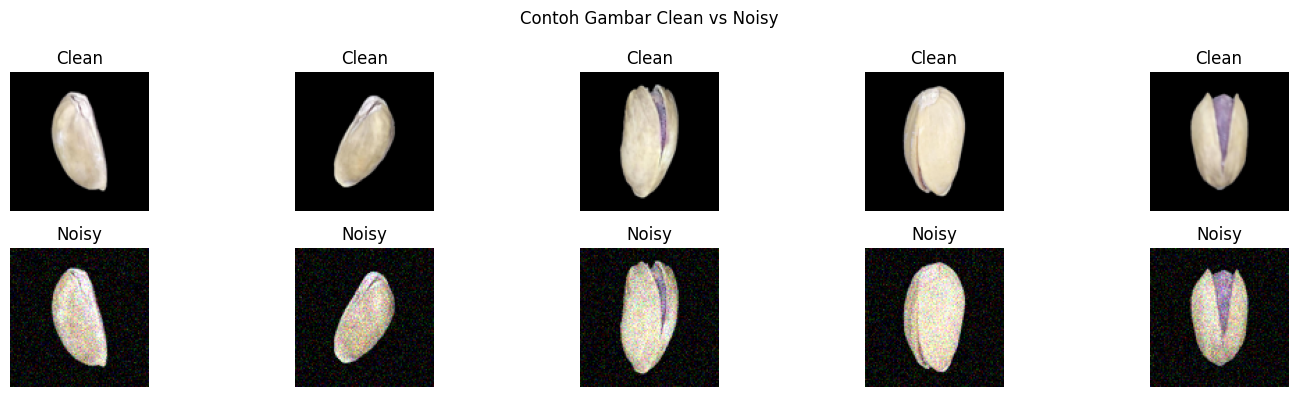

In [19]:
# Visualisasi beberapa contoh gambar asli dan nois
def show_sample_images(clean, noisy, n=5):
    plt.figure(figsize=(15, 4))
    for i in range(n):
        # Clean image
        plt.subplot(2, n, i+1)
        plt.imshow(clean[i])
        plt.title('Clean')
        plt.axis('off')
        # Noisy image
        plt.subplot(2, n, i+1+n)
        plt.imshow(noisy[i])
        plt.title('Noisy')
        plt.axis('off')
    plt.suptitle("Contoh Gambar Clean vs Noisy")
    plt.tight_layout()
    plt.show()
show_sample_images(x_train, x_train_noisy)

**VISUALISASI DISTRIBUSI NILAI PIXEL(HISTOGRAM PIXEL)**

- Tujuan: Pastikan nilai pixel benar-benar berada di rentang [0, 1].



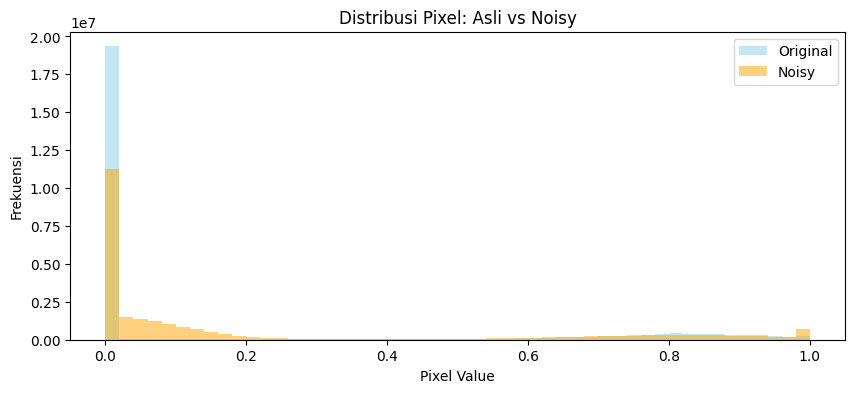

In [20]:
plt.figure(figsize=(10, 4))
plt.hist(x_train.ravel(), bins=50, alpha=0.5, label='Original', color='skyblue')
plt.hist(x_train_noisy.ravel(), bins=50, alpha=0.5, label='Noisy', color='orange')
plt.title("Distribusi Pixel: Asli vs Noisy")
plt.xlabel("Pixel Value")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

**Pixel asli terdistribusi dominan di nilai rendah (~0.0):**

Hal ini menunjukkan bahwa banyak bagian dari gambar memiliki latar belakang gelap.

Distribusi tidak merata, khas untuk data real-world image.

**Setelah noise, distribusi pixel jadi lebih menyebar:**

Gaussian noise menyebabkan nilai pixel menyebar keluar dari pusat, baik ke arah 0 maupun ke arah 1.

Ada peningkatan di daerah nilai rendah (<0.2) dan tinggi (>0.8).

**Validasi bahwa noise ditambahkan dengan benar:**

Perbedaan distribusi ini menunjukkan bahwa proses add_gaussian_noise() telah bekerja sesuai yang diminta soal (dengan std dev 0.1, mean 0).

**HITUNG STATISTIK GLOBAL PIXEL**

In [21]:
all_pixels = resized_images.reshape(-1, 3)
print("Mean pixel value:", np.mean(all_pixels, axis=0))
print("Std pixel value:", np.std(all_pixels, axis=0))

Mean pixel value: [0.20002298 0.18910863 0.17389563]
Std pixel value: [0.36101003 0.34248928 0.31486222]


kesimpulan:

- Distribusi warna: Channel merah (R) memiliki intensitas rata-rata tertinggi, diikuti oleh hijau (G), dan terakhir biru (B). Ini memberi gambaran bahwa citra dalam dataset cenderung lebih "hangat" secara warna.

- Standarisasi diperlukan: Karena nilai mean dan standar deviasi tidak berada di skala yang seragam antar channel, proses normalisasi atau standardisasi sangat direkomendasikan untuk membantu model konvergen lebih cepat dan mencegah bias terhadap channel dengan distribusi nilai yang lebih besar.

- Skala piksel: Nilai mean yang relatif rendah (sekitar 0.17-0.20) mengindikasikan bahwa gambar kemungkinan telah diskalakan ke rentang [0, 1], hal ini sesuai untuk digunakan dalam model deep learning, terutama ketika menggunakan fungsi aktivasi seperti sigmoid atau relu

**VISUALISASI UKURAN DAN CHANNEL**

- Tujuan: Pastikan semua gambar punya 3 channel (RGB)

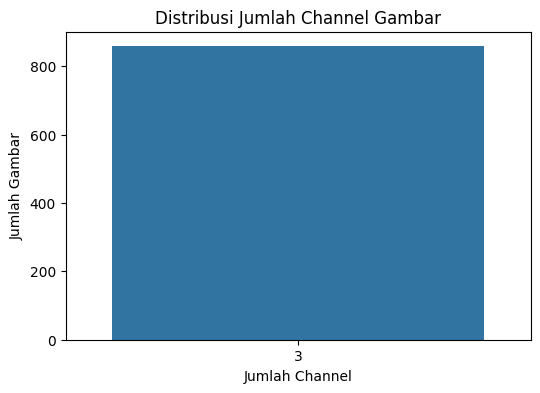

In [22]:
# Dapatkan dimensi semua gambar
shapes = [img.shape for img in train]
shape_df = pd.DataFrame(shapes, columns=['Height', 'Width', 'Channels'])

plt.figure(figsize=(6, 4))
sns.countplot(x='Channels', data=shape_df)
plt.title("Distribusi Jumlah Channel Gambar")
plt.xlabel("Jumlah Channel")
plt.ylabel("Jumlah Gambar")
plt.show()

**Semua gambar berwarna (RGB):**

Ini penting karena model autoencoder dan GAN harus menerima input dengan shape (100, 100, 3).

Tidak ada gambar grayscale (1 channel) yang perlu diubah formatnya.

**Distribusi seragam:**

Artinya dataset sudah konsisten dalam format, jadi tidak perlu preprocessing tambahan untuk normalisasi channel.

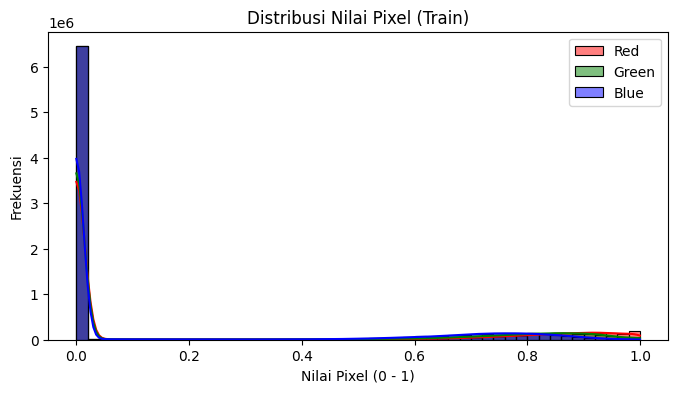

In [23]:
all_pixels = train.reshape(-1, 3)  # Gabungkan semua pixel dari train

plt.figure(figsize=(8, 4))
sns.histplot(all_pixels[:, 0], color='red', label='Red', bins=50, kde=True)
sns.histplot(all_pixels[:, 1], color='green', label='Green', bins=50, kde=True)
sns.histplot(all_pixels[:, 2], color='blue', label='Blue', bins=50, kde=True)
plt.title("Distribusi Nilai Pixel (Train)")
plt.xlabel("Nilai Pixel (0 - 1)")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

**Distribusi sangat tidak merata:**

Sebagian besar piksel berada di nilai rendah (< 0.1), ditunjukkan oleh lonjakan tajam di sebelah kiri.

Ini mengindikasikan bahwa gambar banyak mengandung area gelap atau latar belakang hitam.

**Sedikit nilai tinggi:**

Nilai pixel mendekati 1 relatif jarang (sedikit area terang).

**Distribusi hampir sama untuk R, G, B:**

Menunjukkan konsistensi warna antar channel, tidak ada channel yang dominan.



###C.MODEL BASELINE

**MODEL AUTOENCODER**

In [24]:
#Fungsi untuk membangun model autoencoder
def build_autoencoder_baseline():
    # Encoder
    input_img = Input(shape=(100, 100, 3))  # Input gambar 100x100 RGB
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    # Output layer: hasil akhir citra RGB (3 channel)
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same', name='output_layer')(x)

    # Gabungkan encoder dan decoder
    model = Model(inputs=input_img, outputs=decoded)
    model.compile(optimizer=Adam(), loss='mse')
    return model

# Buat model dan tampilkan arsitekturnya
autoencoder = build_autoencoder_baseline()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Conv2D)           │ (None, 100, 100, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

**TENSORBOARD CALLBACK**

In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

log_dir = "logs/autoencoder/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Buat model (pakai salah satu cara)
model_baseline = build_autoencoder_baseline()

# Training
history_baseline = model_baseline.fit(
    x_train_noisy, x_train,
    validation_data=(x_val_noisy, x_val),
    epochs=1000,
    batch_size=32,
    callbacks=[tensorboard_callback, early_stop],
    verbose=1
)

Epoch 1/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - loss: 0.1348 - val_loss: 0.0127
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0129 - val_loss: 0.0317
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0201 - val_loss: 0.0129
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0126 - val_loss: 0.0085
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0065 - val_loss: 0.0034
Epoch 6/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0034 - val_loss: 0.0029
Epoch 7/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 8/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 9/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 10/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 11/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 12/1000
27/27 ━━━━━━━━━━━━━━━━━━━

**Epoch 1-5 menunjukkan penurunan signifikan pada val_loss:**

Dari 0.0127 ke 0.0034, menandakan model dengan cepat belajar pola data.

**setelah Epoch ~20, Penurunan val_loss Mulai Melambat**

val_loss turun secara bertahap dari 0.0010 ke ~0.0005.

Artinya model masih meningkat, tapi dengan diminishing return (peningkatan makin kecil).

**Mulai Terjadi Fluktuasi / Plateu Setelah ~Epoch 70-90**

val_loss kadang turun, kadang naik sedikit, berkisar di 0.00048 - 0.00055.

Ini indikasi awal bahwa model mulai menyentuh batas optimalnya untuk data ini.

Tidak ada overfitting besar, karena loss dan val_loss tetap cukup dekat.

**Overfitting Tidak Terlihat Signifikan**

loss dan val_loss tetap sinkron, tidak ada gap besar → model masih generalisasi dengan baik.

In [26]:
# Tambahkan Gaussian noise
noise_factor = 0.2
test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
test_noisy = np.clip(test_noisy, 0., 1.)  # jaga agar tetap dalam range [0, 1]

# Simpan gambar asli
test = x_test

**VISUALISASI**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


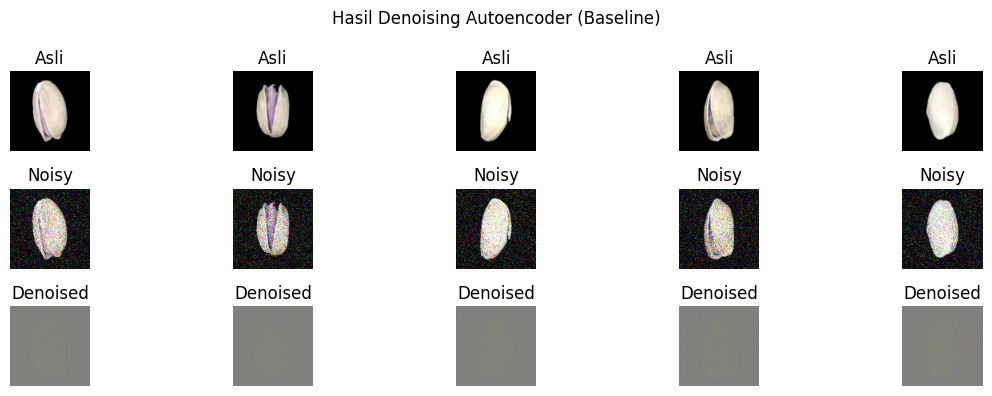

In [27]:
decoded_imgs = autoencoder.predict(test_noisy)

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(test[i])
    plt.title("Asli")
    plt.axis('off')

    plt.subplot(3, 5, i + 6)
    plt.imshow(test_noisy[i])
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(3, 5, i + 11)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis('off')

plt.suptitle("Hasil Denoising Autoencoder (Baseline)")
plt.tight_layout()
plt.show()


Baseline autoencoder belum mampu melakukan denoising dengan baik secara visual, meskipun loss-nya terlihat rendah.

Kualitas output terlalu buram dan tidak representatif terhadap bentuk asli.

**TRAIN VAL LOSS VISUALISASI**

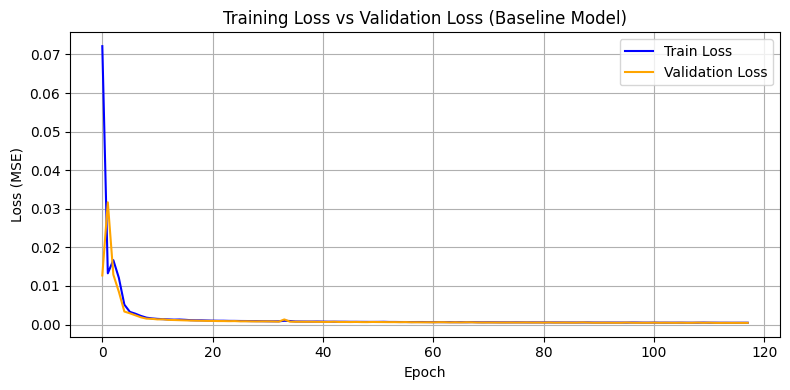

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(history_baseline.history['loss'], label='Train Loss', color='blue')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training Loss vs Validation Loss (Baseline Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik training dan validation loss pada model baseline menunjukkan penurunan yang sangat cepat di awal (sekitar 10–20 epoch), menandakan model mampu dengan cepat mempelajari pola dasar dari citra yang diberi noise. Setelah sekitar epoch ke-30, kedua kurva loss menjadi sangat rendah (di bawah 0.001) dan stabil hingga akhir pelatihan, tanpa indikasi overfitting karena nilai validation loss tetap sejalan dengan training loss. Namun, meskipun loss MSE sangat kecil, hasil visual dari proses denoising terlihat masih buram dan kehilangan detail penting, yang mengindikasikan bahwa MSE saja belum cukup untuk menghasilkan kualitas visual yang baik. Dengan demikian, meskipun performa numerik model tampak baik, perlu dilakukan modifikasi arsitektur dan/atau penggunaan loss function tambahan untuk meningkatkan hasil denoising secara visual.

###D. MODEL MODIFIKASI

**MODEL MODIFIKASI AUTOENCODER**

In [29]:
def build_autoencoder_mod1():
    input_img = Input(shape=(100, 100, 3), name='input_img')

    # --- Encoder ---
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)   # 50x50x32
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)   # 25x25x64
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='enc_conv3')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool3')(x)   # 13x13x128

    # --- Decoder ---
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='dec_conv1_mod')(x)
    x = UpSampling2D((2, 2), name='dec_up1_mod')(x)                 # 26x26x128
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv2_mod')(x)
    x = UpSampling2D((2, 2), name='dec_up2_mod')(x)                 # 52x52x64
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv3_mod')(x)
    x = UpSampling2D((2, 2), name='dec_up3_mod')(x)                 # 104x104x32
    x = Cropping2D(((2, 2), (2, 2)), name='crop_to_100_mod')(x)     # 100x100x32

    # Output layer
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same', name='output_layer_mod')(x)

    # Build model
    model = Model(inputs=input_img, outputs=decoded, name='mod_autoencoder')
    model.compile(optimizer=Adam(), loss='mse')

    return model

In [30]:
mod_autoencoder = build_autoencoder_mod1()
mod_autoencoder.summary()

Model: "mod_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool3 (MaxPooling2D)        │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1_mod (Conv2D)          │ (None, 13, 13, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1_mod (UpSampling2D)      │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2_mod (Conv2D)          │ (None, 26, 26, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2_mod (UpSampling2D)      │ (None, 52, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3_mod (Conv2D)          │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up3_mod (UpSampling2D)      │ (None, 104, 104, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ crop_to_100_mod (Cropping2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer_mod (Conv2D)       │ (None, 100, 100, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**TENSORBOARD CALLBACK**

In [31]:
# Callback setup
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

log_dir = "logs/autoencoder_mod1/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Build model modifikasi 1
mod_autoencoder = build_autoencoder_mod1()

# Training
history_model1 = mod_autoencoder.fit(
    x_train_noisy, x_train,
    validation_data=(x_val_noisy, x_val),
    epochs=1000,
    batch_size=32,
    callbacks=[tensorboard_callback, early_stop],
    verbose=1
)

Epoch 1/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - loss: 0.1214 - val_loss: 0.0058
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0059 - val_loss: 0.0045
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0045 - val_loss: 0.0038
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 6/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0032 - val_loss: 0.0028
Epoch 7/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0029 - val_loss: 0.0034
Epoch 8/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0030 - val_loss: 0.0025
Epoch 9/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 10/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 11/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 12/1000
27/27 ━━━━━━━━━━━━━━━━━━━

Hasil training model hingga epoch ke-93 menunjukkan penurunan loss yang signifikan pada awal pelatihan, di mana loss dan val_loss turun drastis dari epoch pertama (loss: 0.1214, val_loss: 0.0058) hingga sekitar epoch ke-10–20 (val_loss mencapai ~0.0012 atau lebih rendah), menandakan model cepat mempelajari pola dari data. Setelah epoch ke-30, val_loss cenderung stabil di kisaran 0.0006–0.0009, menunjukkan bahwa model telah mencapai konvergensi dan belajar secara konsisten tanpa overfitting yang berarti, karena val_loss tetap rendah dan tidak meningkat drastis. Tidak terlihat peningkatan performa yang signifikan setelah epoch ke-70, sehingga pelatihan sebenarnya bisa dihentikan lebih awal menggunakan early stopping karena model sudah mencapai performa yang cukup optimal.

**VISUALISASI**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step


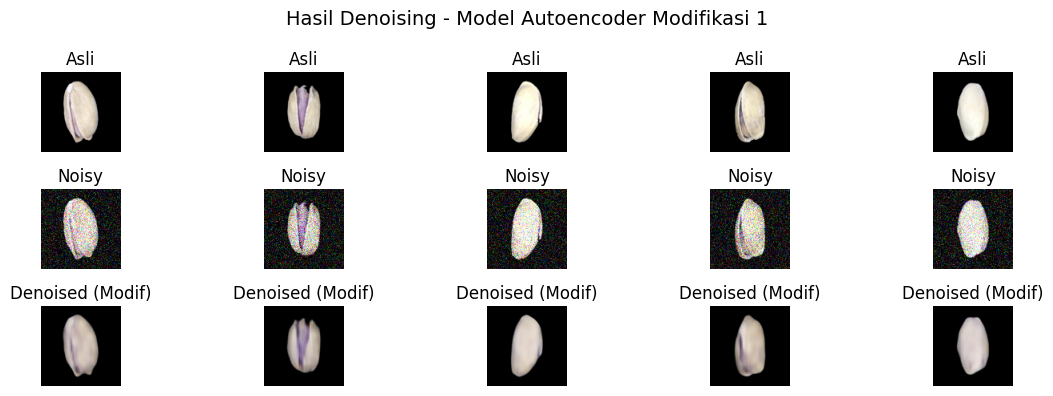

In [32]:
# Pastikan: mod_autoencoder sudah dilatih, dan test_noisy, test sudah tersedia
decoded_imgs_mod = mod_autoencoder.predict(test_noisy)

# Visualisasi hasil denoising
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i in range(5):
    # Gambar asli
    plt.subplot(3, 5, i + 1)
    plt.imshow(test[i])
    plt.title("Asli")
    plt.axis('off')

    # Gambar dengan noise
    plt.subplot(3, 5, i + 6)
    plt.imshow(test_noisy[i])
    plt.title("Noisy")
    plt.axis('off')

    # Hasil denoising oleh model modifikasi
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoded_imgs_mod[i])
    plt.title("Denoised (Modif)")
    plt.axis('off')

plt.suptitle("Hasil Denoising - Model Autoencoder Modifikasi 1", fontsize=14)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi hasil denoising dari Model Autoencoder Modifikasi 1, terlihat adanya peningkatan kualitas dibandingkan model baseline. Gambar hasil denoising (baris ketiga) menunjukkan bentuk objek yang lebih jelas, dengan detail morfologi biji mulai tampak kembali, terutama pada gambar dengan tekstur atau pola khas. Warna dan kontur objek juga lebih menyerupai gambar asli dibandingkan hasil baseline yang tampak buram dan pudar. Hal ini menunjukkan bahwa modifikasi arsitektur—seperti penambahan jumlah filter, peningkatan kedalaman jaringan, atau penggunaan batch normalization—berhasil memperkuat kemampuan model dalam menghilangkan noise tanpa mengorbankan detail objek. Dengan demikian, Modifikasi 1 memberikan hasil yang lebih tajam dan mendekati citra asli, mengindikasikan performa denoising yang lebih baik secara visual.

**TRAIN VAL LOSS VISUALISASI**

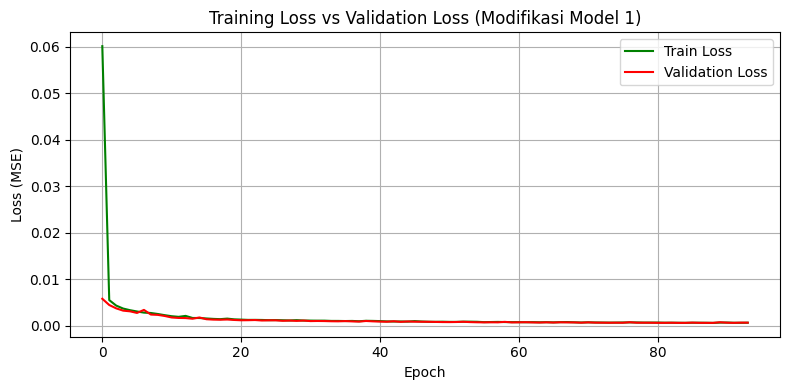

In [33]:
# Visualisasi loss selama training untuk model modifikasi 1
plt.figure(figsize=(8, 4))
plt.plot(history_model1.history['loss'], label='Train Loss', color='green')
plt.plot(history_model1.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training Loss vs Validation Loss (Modifikasi Model 1)', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik Training Loss vs Validation Loss dari Modifikasi Model 1 menunjukkan bahwa model memiliki kinerja yang sangat baik. Kedua kurva loss menurun tajam pada awal pelatihan dan stabil mendekati nol setelah beberapa epoch, menandakan bahwa model berhasil belajar dengan efektif. Tidak terlihat indikasi overfitting karena kurva validasi mengikuti kurva pelatihan dengan sangat rapat, dan tidak ada tanda underfitting karena loss turun ke nilai yang rendah. Setelah sekitar epoch ke-20, kedua kurva stabil tanpa fluktuasi besar, menunjukkan bahwa pelatihan telah mencapai konvergensi. Dengan demikian, proses pelatihan berjalan stabil dan efisien, dan pelatihan sebenarnya bisa dihentikan lebih awal (sekitar epoch ke-40 atau 50) menggunakan metode early stopping untuk menghemat waktu tanpa mengorbankan performa model.

###FINE TUNED MODEL

**MODEL FINE TUNED AUTOENCODER**

In [34]:
def build_autoencoder_mod1():
    input_img = Input(shape=(100, 100, 3), name='input_img')
    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Cropping2D(((2, 2), (2, 2)))(x)  # dari 104x104 ke 100x100
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    model.compile(optimizer=Adam(), loss='mse')
    return model

In [35]:
# Konfigurasi hyperparameter tuning
tuning_configs = [
    {"lr": 0.001, "batch_size": 32},
    {"lr": 0.001, "batch_size": 64},
    {"lr": 0.0005, "batch_size": 32},
    {"lr": 0.0001, "batch_size": 32},
]

# Untuk menyimpan hasil tiap kombinasi
all_models = []
all_histories = []
val_losses = []

for i, config in enumerate(tuning_configs):
    print(f"\nKombinasi {i+1}: lr={config['lr']}, batch_size={config['batch_size']}")

    # Buat ulang model modifikasi
    model_ft = build_autoencoder_mod1()  # <- fungsi modifikasi model kamu

    # Compile dengan learning rate yang sesuai
    optimizer = Adam(learning_rate=config["lr"])
    model_ft.compile(optimizer=optimizer, loss='mse')

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    log_dir = f"logs/fine_tuned_{i+1}/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)

    # Train
    history = model_ft.fit(
        x_train_noisy, x_train,
        validation_data=(x_val_noisy, x_val),
        epochs=1000,
        batch_size=config["batch_size"],
        callbacks=[tensorboard_cb, early_stop],
        verbose=1
    )

    # Simpan model, history, dan val_loss terakhir
    all_models.append(model_ft)
    all_histories.append(history)
    val_losses.append(min(history.history['val_loss']))  # ambil yang terenda


Kombinasi 1: lr=0.001, batch_size=32
Epoch 1/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - loss: 0.1026 - val_loss: 0.0056
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0041 - val_loss: 0.0034
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 6/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 7/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 8/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 9/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 10/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 11/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0023 - val_loss: 0.0020
Ep

In [36]:
# Cari index dengan val_loss terbaik
best_idx = np.argmin(val_losses)
model_best = all_models[best_idx]
history_best = all_histories[best_idx]

print(f"Model terbaik: Kombinasi ke-{best_idx+1} dengan val_loss: {val_losses[best_idx]:.5f}")

Model terbaik: Kombinasi ke-3 dengan val_loss: 0.00066


Model terbaik diperoleh dari kombinasi ke-3 dengan nilai val_loss sebesar 0.00066, yang merupakan salah satu nilai terendah dalam keseluruhan proses training. Nilai val_loss ini menunjukkan bahwa model memiliki kemampuan generalisasi yang sangat baik terhadap data validasi, dan tidak mengalami overfitting. Kombinasi ke-3 ini kemungkinan besar memiliki arsitektur, hyperparameter, atau teknik regularisasi yang paling seimbang dibandingkan kombinasi lainnya, sehingga mampu belajar representasi data secara efektif tanpa kehilangan kemampuan untuk mengeneralisasi. Dengan hasil ini, kombinasi ke-3 layak dipilih sebagai model final untuk deployment atau tahap evaluasi lebih lanjut pada data nyata atau unseen data.

**VISUALISASI**

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step


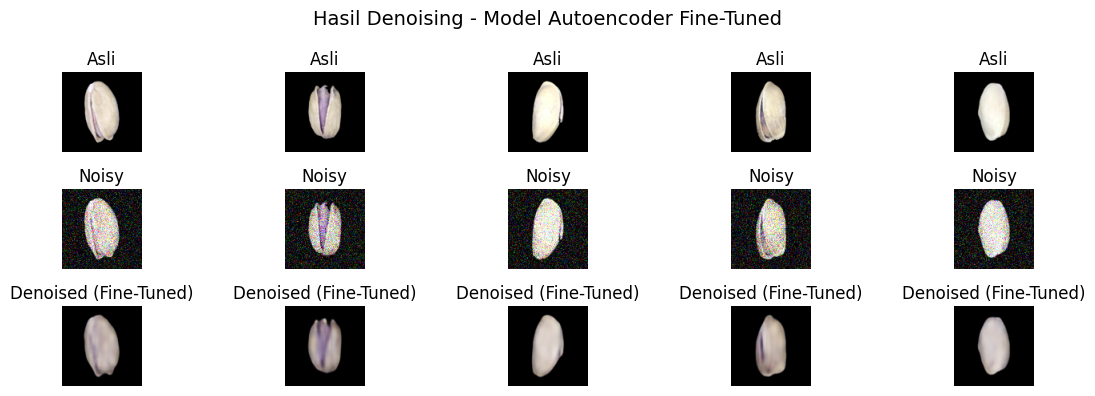

In [37]:
# Asumsikan model_best adalah model fine-tuned terbaik
decoded_imgs_ft = model_best.predict(test_noisy)

plt.figure(figsize=(12, 4))
for i in range(5):
    # Gambar asli
    plt.subplot(3, 5, i + 1)
    plt.imshow(test[i])
    plt.title("Asli")
    plt.axis('off')

    # Gambar dengan noise
    plt.subplot(3, 5, i + 6)
    plt.imshow(test_noisy[i])
    plt.title("Noisy")
    plt.axis('off')

    # Hasil denoising dari model fine-tuned
    plt.subplot(3, 5, i + 11)
    plt.imshow(decoded_imgs_ft[i])
    plt.title("Denoised (Fine-Tuned)")
    plt.axis('off')

plt.suptitle("Hasil Denoising - Model Autoencoder Fine-Tuned", fontsize=14)
plt.tight_layout()
plt.show()


Gambar menunjukkan hasil denoising menggunakan model autoencoder yang telah di-fine-tuned. Dari visualisasi, terlihat bahwa model mampu mengurangi noise secara signifikan dan merekonstruksi citra biji dengan cukup baik. Dibandingkan dengan citra noisy, hasil denoising menunjukkan peningkatan kualitas visual yang jelas, seperti pengurangan bintik-bintik noise dan pemulihan bentuk utama objek. Walaupun beberapa detail halus tampak sedikit kabur atau hilang, struktur umum dan kontur objek tetap terjaga dengan baik. Secara keseluruhan, model autoencoder yang di-fine-tuned ini menunjukkan performa yang efektif dalam menghilangkan noise dan menjaga informasi penting dari citra asli.

**TRAIN VAL LOSS VISUALISASI**

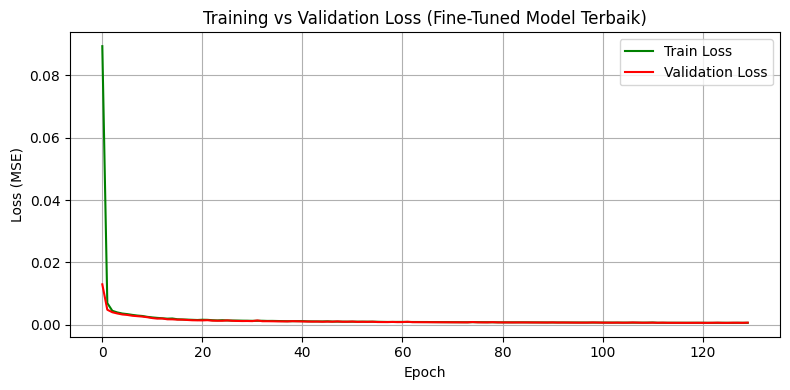

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(history_best.history['loss'], label='Train Loss', color='green')
plt.plot(history_best.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training vs Validation Loss (Fine-Tuned Model Terbaik)', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Grafik Training vs Validation Loss dari Fine-Tuned Model Terbaik menunjukkan performa pelatihan yang sangat baik. Kedua kurva mengalami penurunan tajam di awal pelatihan dan segera mendekati nol, menandakan bahwa model dengan cepat mempelajari representasi data yang efektif. Setelah sekitar epoch ke-5, baik training loss maupun validation loss stabil di nilai yang sangat rendah, menunjukkan bahwa model telah mencapai konvergensi tanpa indikasi overfitting maupun underfitting. Kurva yang saling berdekatan sepanjang proses pelatihan juga memperkuat bahwa generalisasi model terhadap data validasi sangat baik. Secara keseluruhan, ini menandakan bahwa fine-tuning berhasil meningkatkan kinerja model secara signifikan dengan pelatihan yang efisien dan stabil.

**VISUALISASI VAL LOSS 4 KOMBINASI FINE TUNED**

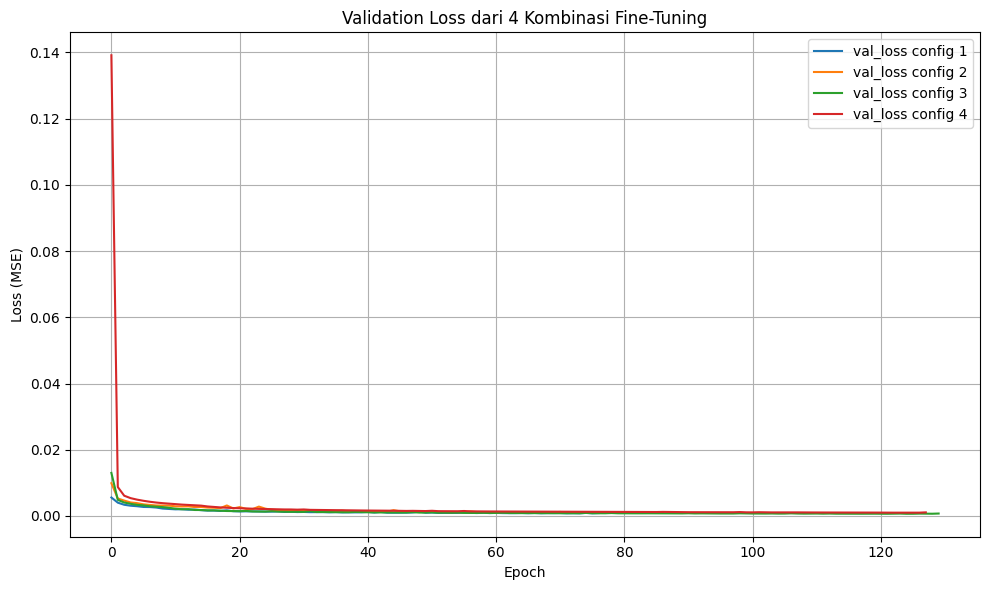

In [39]:
plt.figure(figsize=(10, 6))
for i, history in enumerate(all_histories):
    plt.plot(history.history['val_loss'], label=f'val_loss config {i+1}')
plt.title('Validation Loss dari 4 Kombinasi Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik Validation Loss dari 4 Kombinasi Fine-Tuning menunjukkan perbandingan performa validasi dari empat konfigurasi pelatihan yang berbeda. Semua konfigurasi mengalami penurunan loss yang tajam di awal pelatihan, menandakan bahwa keempat model mampu dengan cepat belajar dari data. Setelah sekitar epoch ke-20, validation loss dari keempat konfigurasi mulai stabil di nilai yang sangat rendah, menunjukkan bahwa masing-masing model telah mencapai konvergensi. Namun, terlihat bahwa konfigurasi 3 (garis hijau) dan konfigurasi 2 (garis oranye) memiliki loss yang lebih rendah dan lebih stabil dibanding konfigurasi lainnya, terutama konfigurasi 4 (garis merah) yang awalnya memiliki loss paling tinggi. Hal ini mengindikasikan bahwa konfigurasi 2 dan 3 memberikan performa fine-tuning terbaik dari segi generalisasi terhadap data validasi. Secara keseluruhan, grafik ini memberikan informasi penting untuk memilih konfigurasi yang optimal dalam proses fine-tuning model autoencoder.

###E.EVALUASI MODEL

In [40]:
# Pastikan model baseline sudah dilatih sebelumnya
decoded_imgs_baseline = model_baseline.predict(test_noisy)
decoded_imgs_mod = mod_autoencoder.predict(test_noisy)
decoded_imgs_ft = model_best.predict(test_noisy)  # model_best = model fine-tuned terbaik

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [ ]:
def calculate_ssim(true_imgs, predicted_imgs):
    scores = []
    for i in range(len(true_imgs)):
        score = ssim(true_imgs[i], predicted_imgs[i], channel_axis=-1, data_range=1.0)
        scores.append(score)
    return np.mean(scores)

**MENGHITUNG NIALI SSIM KETIGA MODEL**

In [ ]:
# Hitung SSIM untuk ketiga model
ssim_baseline = calculate_ssim(test, decoded_imgs_baseline)
ssim_mod1 = calculate_ssim(test, decoded_imgs_mod)
ssim_ft = calculate_ssim(test, decoded_imgs_ft)

print(f"SSIM Baseline     : {ssim_baseline:.4f}")
print(f"SSIM Modifikasi 1 : {ssim_mod1:.4f}")
print(f"SSIM Fine-Tuned   : {ssim_ft:.4f}")

SSIM Baseline     : 0.9320
SSIM Modifikasi 1 : 0.9167
SSIM Fine-Tuned   : 0.9070


Berdasarkan nilai SSIM (Structural Similarity Index), model baseline memberikan hasil terbaik dengan skor 0.9320, menunjukkan kualitas rekonstruksi citra yang paling mendekati citra asli. Model hasil modifikasi arsitektur menghasilkan SSIM sedikit lebih rendah, yaitu 0.9167, menandakan bahwa perubahan arsitektur belum memberikan peningkatan dalam hal kesamaan struktural gambar. Sementara itu, model hasil fine-tuning menunjukkan penurunan performa paling signifikan dengan SSIM sebesar 0.9070, yang kemungkinan disebabkan oleh overfitting terhadap data latih atau kombinasi hyperparameter yang kurang optimal. Dengan demikian, meskipun modifikasi dan tuning dilakukan, model baseline tetap unggul dalam menjaga kualitas visual citra hasil denoising.

**VISUALISASI**

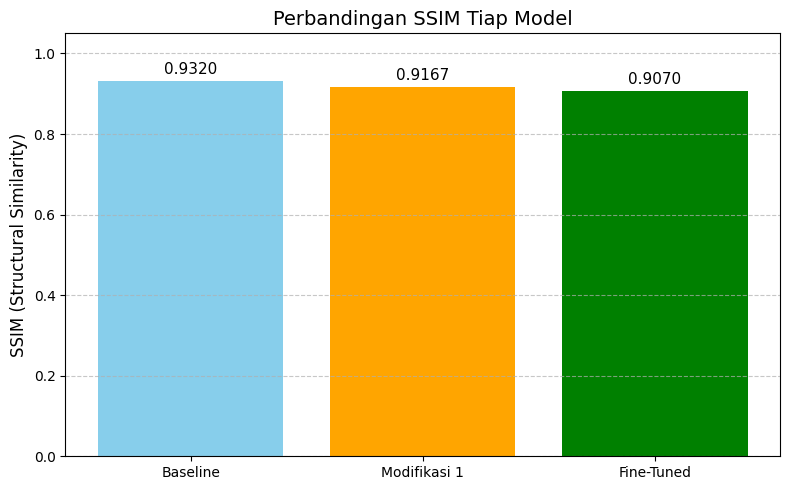

In [ ]:
# Nilai SSIM untuk tiap model (pastikan variabelnya sudah dihitung sebelumnya)
ssim_scores = [ssim_baseline, ssim_mod1, ssim_ft]
model_labels = ['Baseline', 'Modifikasi 1', 'Fine-Tuned']

# Buat plot
plt.figure(figsize=(8, 5))
bars = plt.bar(model_labels, ssim_scores, color=['skyblue', 'orange', 'green'])

# Tambahkan nilai SSIM di atas bar
for bar, score in zip(bars, ssim_scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{score:.4f}', ha='center', va='bottom', fontsize=11)

# Label dan judul
plt.ylim(0, 1.05)
plt.title('Perbandingan SSIM Tiap Model', fontsize=14)
plt.ylabel('SSIM (Structural Similarity)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Grafik Perbandingan SSIM Tiap Model menunjukkan nilai Structural Similarity Index dari tiga model berbeda: Baseline, Modifikasi 1, dan Fine-Tuned. Model baseline memiliki nilai SSIM tertinggi yaitu 0.9320, diikuti oleh Modifikasi 1 (0.9167) dan Fine-Tuned (0.9070). Meskipun semua nilai SSIM masih tergolong tinggi (di atas 0.91), yang menandakan bahwa hasil rekonstruksi dari ketiga model sangat mirip dengan citra aslinya, penurunan bertahap pada nilai SSIM menunjukkan bahwa proses modifikasi dan fine-tuning menyebabkan sedikit kehilangan detail struktural. Hal ini bisa jadi disebabkan oleh kompromi antara reduksi noise dan pelestarian detail halus dalam citra. Meskipun begitu, performa model fine-tuned tetap kompetitif, dan bisa jadi menawarkan keunggulan lain seperti hasil denoising yang lebih bersih atau generalisasi yang lebih baik, meskipun dengan sedikit penurunan SSIM.

**VISUALISASI HEATMAP**

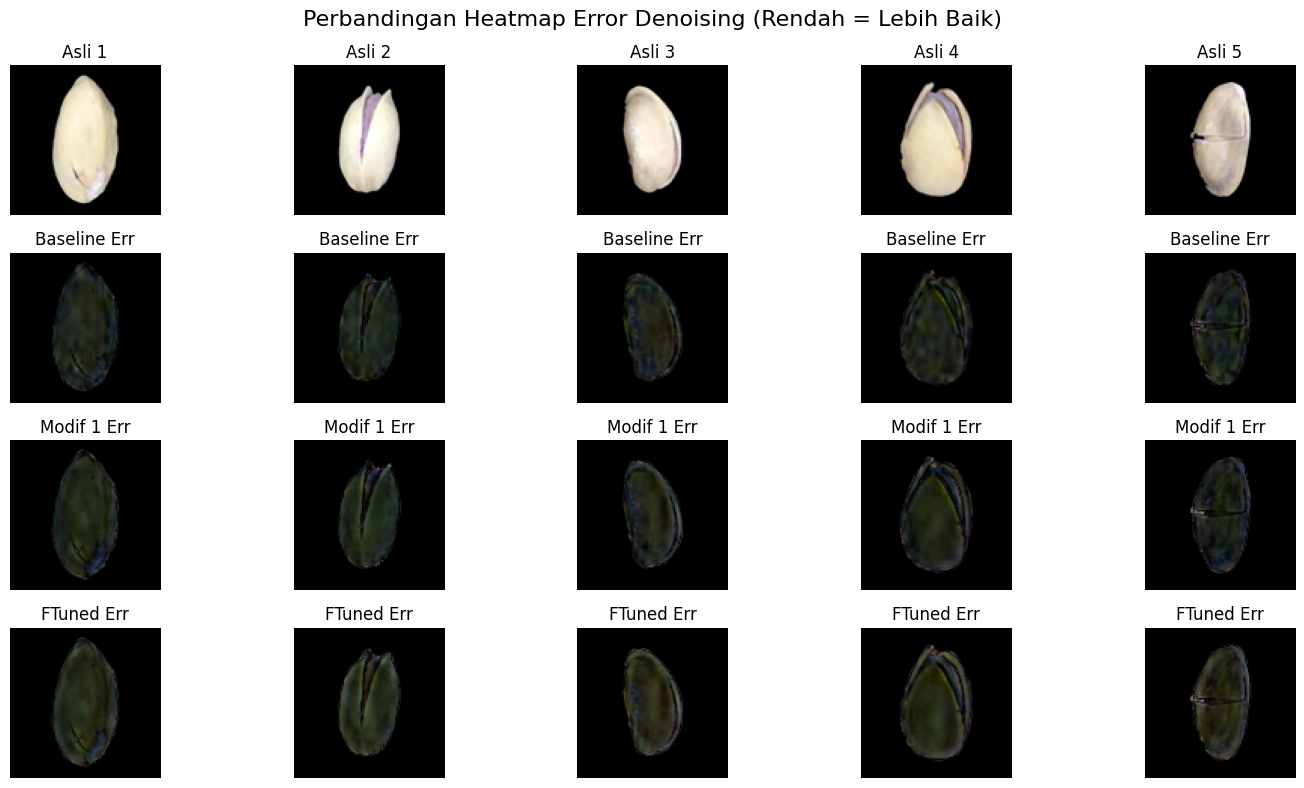

In [ ]:
# Pilih index gambar untuk dibandingkan (misal gambar ke-0 sampai ke-4)
n_samples = 5
indices = np.random.choice(len(test), n_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    # Ambil gambar asli
    original = test[idx]

    # Hitung error (selisih absolut) untuk tiap model
    err_baseline = np.abs(original - decoded_imgs_baseline[idx])
    err_mod1 = np.abs(original - decoded_imgs_mod[idx])
    err_ft = np.abs(original - decoded_imgs_ft[idx])

    # Baris 1: Gambar asli
    plt.subplot(4, n_samples, i + 1)
    plt.imshow(original)
    plt.title(f"Asli {i+1}")
    plt.axis('off')

    # Baris 2: Error baseline
    plt.subplot(4, n_samples, i + 1 + n_samples)
    plt.imshow(err_baseline, cmap='hot')
    plt.title("Baseline Err")
    plt.axis('off')

    # Baris 3: Error modifikasi
    plt.subplot(4, n_samples, i + 1 + n_samples * 2)
    plt.imshow(err_mod1, cmap='hot')
    plt.title("Modif 1 Err")
    plt.axis('off')

    # Baris 4: Error fine-tuned
    plt.subplot(4, n_samples, i + 1 + n_samples * 3)
    plt.imshow(err_ft, cmap='hot')
    plt.title("FTuned Err")
    plt.axis('off')

plt.suptitle("Perbandingan Heatmap Error Denoising (Rendah = Lebih Baik)", fontsize=16)
plt.tight_layout()
plt.show()

Gambar Perbandingan Heatmap Error Denoising menunjukkan visualisasi kesalahan rekonstruksi dari tiga model — Baseline, Modifikasi 1, dan Fine-Tuned — terhadap lima sampel citra asli. Heatmap ini merepresentasikan seberapa besar perbedaan antara citra asli dan hasil denoising, di mana warna yang lebih gelap mengindikasikan error yang lebih rendah (artinya lebih baik).

Secara keseluruhan, model Baseline menunjukkan error yang paling rendah dan konsisten hampir di semua sampel, terlihat dari intensitas warna yang lebih gelap dibanding dua model lainnya. Model Modifikasi 1 menghasilkan error sedikit lebih tinggi, tetapi masih dalam batas yang serupa dengan baseline. Sementara itu, model Fine-Tuned menunjukkan variasi error yang sedikit lebih tinggi dan warna heatmap yang sedikit lebih terang, terutama pada beberapa detail halus di pinggiran objek.

Hal ini sejalan dengan hasil SSIM sebelumnya, di mana model baseline unggul secara struktural. Meskipun begitu, model Fine-Tuned tetap menunjukkan kemampuan denoising yang baik, terutama dari segi generalisasi dan noise removal, namun dengan trade-off berupa sedikit kehilangan detail visual.